[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_06/assignments/assignment_combined_5_6.ipynb)

# Assignment 5 & 6: HRTEM Simulation and CTF Analysis

In this assignment, you will use the `abTEM` package to perform a multislice High-Resolution Transmission Electron Microscopy (HRTEM) simulation. You will build an atomic model, calculate its projected potential, simulate the electron wave propagation, and apply different Contrast Transfer Functions (CTFs) to understand how microscope parameters affect the final image.

## Learning Objectives
1. Understand the multislice algorithm for HRTEM simulation.
2. Explore the effects of the Contrast Transfer Function (CTF), including spherical aberration ($C_s$) and defocus ($\Delta f$).
3. Analyze the impact of aberration correction and noise on image quality.

---

## Part 1: Setup and Building the Atomic Model

First, we import the necessary libraries and build our atomic model. We will use a Silicon Nitride (Si$_3$N$_4$) crystal structure.

In [3]:
%matplotlib inline

import abtem
import ase
import numpy as np
import matplotlib.pyplot as plt

print(f"abTEM version: {abtem.__version__}")

abTEM version: 1.0.6


### Define the Si$_3$N$_4$ Structure
We use the Atomic Simulation Environment (`ase`) to define the unit cell by providing the atomic positions and cell dimensions.

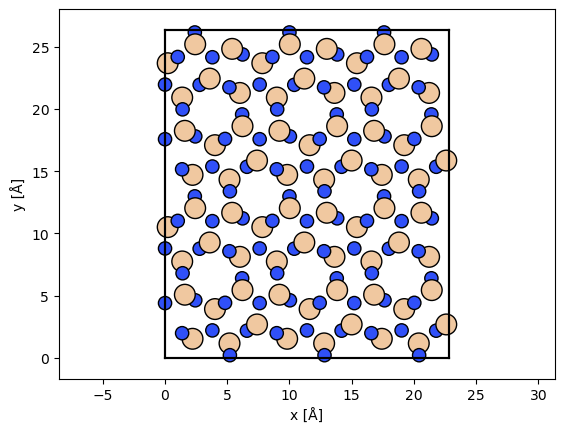

In [5]:
structure = ase.Atoms(
    'Si6N8',
    positions=[
      (4.015308131006949, 3.9110253242355126, 2.1788993100000003),
      (2.422878997737693, -1.15285715796029, 0.72629977),
      (5.3947013511357, -1.5218461833564767, 0.72629977),
      (2.2098430845971873, 1.521846183356477, 2.1788993100000003),
      (5.181665437995193, 1.1528571579602902, 2.1788993100000003),
      (3.5892363047259375, -3.9110253242355126, 0.72629977),
      (3.8022722178664434, 2.195242888517426, 2.1788993100000003),
      (3.802272217866444, -2.1952428885174267, 0.72629977),
      (6.2321062558996125, -1.9713791971906662, 2.1788993100000003),
      (4.8233175932090955, 4.411472738097657, 0.72629977),
      (5.211060880556961, 0.20287673026395847, 0.72629977),
      (2.3934835551759255, -0.20287673026395803, 2.1788993100000003),
      (1.3724381798332734, 1.9713791971906653, 0.72629977),
      (2.781226842523792, -4.411472738097657, 2.1788993100000003),
    ],
    cell=[7.6045, 7.6045, 2.9052, 90, 90, 120]
)

structure_orthogonal = abtem.orthogonalize_cell(structure)
abtem.show_atoms(structure_orthogonal * (3, 2, 6), plane='xy');

---

## Part 2: Calculate Projected Potentials

**TASK 1:** Calculate the projected potentials for the structure.
1. Create a `FrozenPhonons` object using the orthogonalized structure tiled by `(3, 2, 17)`. This gives a thickness of ~5 nm. Use 8 configurations and a thermal sigma of 0.1 Å for both Si and N.
2. Create a `Potential` object using the frozen phonons, with a sampling of 0.1 Å, slice thickness of 2.0 Å, and the 'kirkland' parametrization.
3. Plot the mean-projected potential.

[########################################] | 100% Completed | 994.18 ms


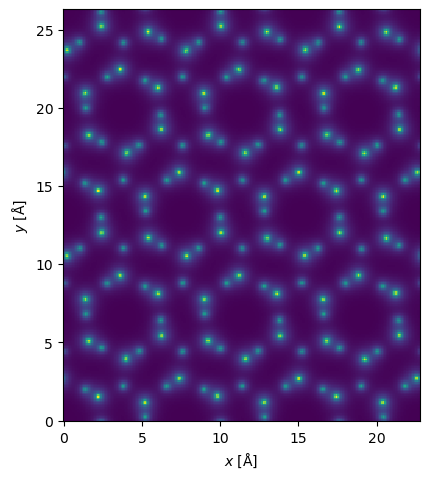

In [6]:
# TASK 1: Create FrozenPhonons
# Tile the structure by (3, 2, 17) to get ~5 nm thickness
# Use 8 configurations and a thermal sigma of 0.1 Å for both Si and N
frozen_phonons = abtem.FrozenPhonons(
    structure_orthogonal * (3, 2, 17),
    num_configs=8,
    sigmas={'Si': 0.1, 'N': 0.1},  # thermal displacement in Å
)

# TASK 1: Create the Potential object
# Use sampling=0.1 Å, slice_thickness=2.0 Å, and the 'kirkland' parametrization
potential = abtem.Potential(
    frozen_phonons,
    sampling=0.1,           # real-space sampling in Å/pixel
    slice_thickness=2.0,    # thickness of each projected slice in Å
    parametrization='kirkland',
)

# TASK 1: Plot the mean projected potential
# .project() collapses along z; .show() displays it
potential.project().show(cmap='viridis');


---

## Part 3: HRTEM Plane Wave Multislice Simulation

**TASK 2:** Perform the multislice simulation.
1. Initialize a `PlaneWave` with an energy of 300 keV.
2. Run the `multislice` algorithm using the potential you calculated.
3. Plot the mean intensity of the exit waves.

[########################################] | 100% Completed | 1.05 sms


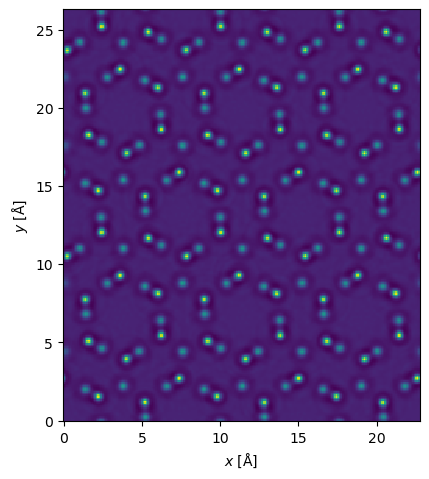

In [7]:
# TASK 2: Initialize the PlaneWave with 300 keV energy
wave = abtem.PlaneWave(energy=300e3)  # energy in eV

# TASK 2: Run the multislice simulation
# This propagates the wave through each slice of the potential
exit_waves = wave.multislice(potential)

# TASK 2: Plot the mean intensity of the exit waves
# .intensity() computes |ψ|², .mean(0) averages over frozen phonon configs
exit_waves.intensity().mean(0).show(cmap='viridis');


---

## Part 4: Contrast Transfer Function (CTF)

The exit wave represents the electron wave immediately after leaving the sample. To simulate the final image, we must apply the Contrast Transfer Function (CTF) of the microscope.

**TASK 3:** Define and apply different CTFs.
1. Define an **uncorrected CTF** with $C_{10} = -600$ Å (defocus) and $C_{30} = 1.3 \times 10^7$ Å ($C_s = 1.3$ mm).
2. Define an **aberration-corrected CTF** with $C_{10} = 30$ Å and $C_{30} = -8 \times 10^4$ Å.
3. Plot both CTFs to compare them.
4. Apply both CTFs to your `exit_waves` and plot the resulting mean image intensities.

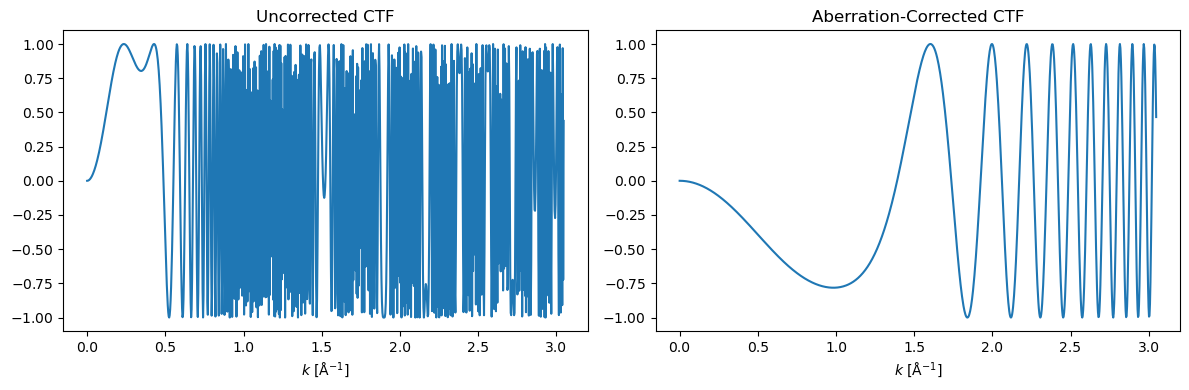

In [10]:
# TASK 3a: Define the UNCORRECTED CTF
parameters_uncorrected = {
    'C10': -600,
    'C30': 1.3e7,
}
ctf_uncorrected = abtem.CTF(
    energy=300e3,
    aberration_coefficients=parameters_uncorrected
)

# TASK 3b: Define the ABERRATION-CORRECTED CTF
parameters_corrected = {
    'C10': 30,
    'C30': -8e4,
}
ctf_corrected = abtem.CTF(
    energy=300e3,
    aberration_coefficients=parameters_corrected
)

# TASK 3c: Plot both CTFs as radial profiles
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ctf_uncorrected.profiles(max_angle=60).show(ax=axes[0], units="mrad")
axes[0].set_title("Uncorrected CTF")

ctf_corrected.profiles(max_angle=60).show(ax=axes[1], units="mrad")
axes[1].set_title("Aberration-Corrected CTF")

plt.tight_layout()
plt.show()

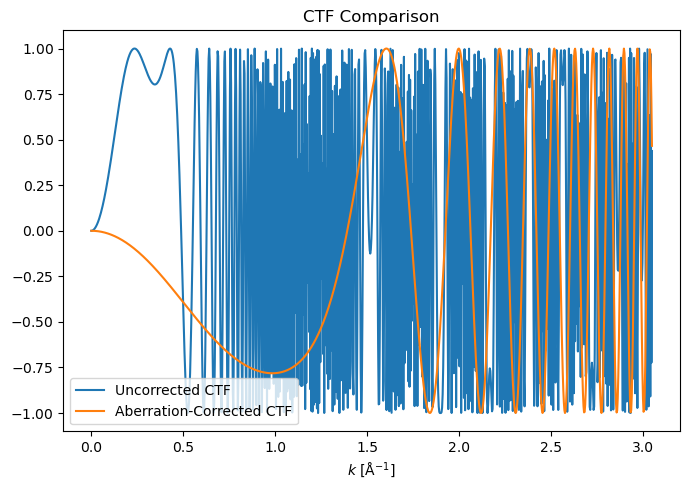

In [11]:
# Plot both CTF profiles on the same graph
fig, ax = plt.subplots(figsize=(7, 5))

ctf_uncorrected.profiles(max_angle=60).show(
    ax=ax,
    units="mrad",
    label="Uncorrected CTF"
)

ctf_corrected.profiles(max_angle=60).show(
    ax=ax,
    units="mrad",
    label="Aberration-Corrected CTF"
)

ax.set_title("CTF Comparison")
ax.legend()
plt.tight_layout()
plt.show()

[########################################] | 100% Completed | 738.03 ms
[########################################] | 100% Completed | 734.73 ms


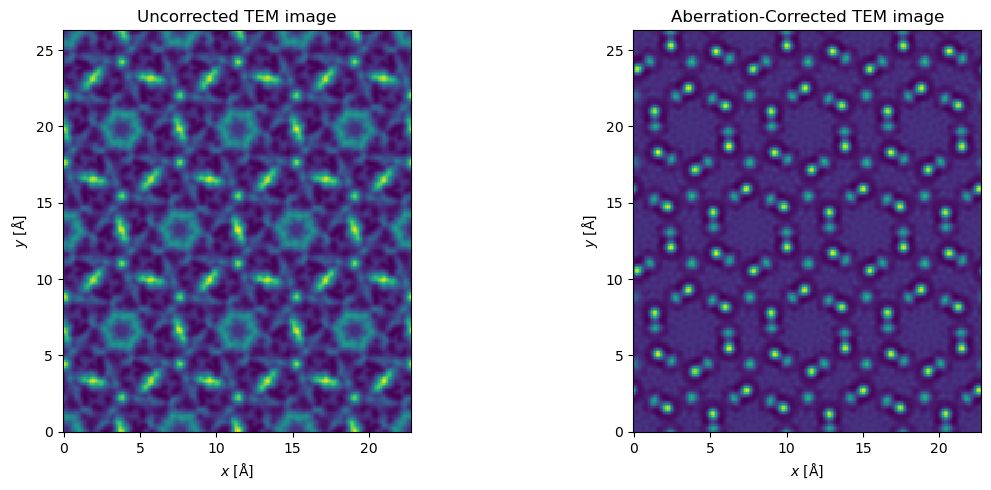

In [13]:
# TASK 3d: Apply each CTF to the exit waves
# .apply_ctf() convolves the exit wave with the CTF in Fourier space
image_uncorrected = exit_waves.apply_ctf(ctf_uncorrected)
image_corrected   = exit_waves.apply_ctf(ctf_corrected)

# TASK 3d: Plot the resulting mean image intensities side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

image_uncorrected.intensity().mean(0).show(cmap='viridis', ax=axes[0])
axes[0].set_title('Uncorrected TEM image')

image_corrected.intensity().mean(0).show(cmap='viridis', ax=axes[1])
axes[1].set_title('Aberration-Corrected TEM image')

plt.tight_layout()
plt.show()


---

## Part 5: Noise and Dose

Real TEM images are affected by Poisson noise due to the finite electron dose.

**TASK 4:** Apply Poisson noise to your images.
1. Use `abtem.noise.poisson_noise` to apply a dose of $100$ $e^-$/Å$^2$ to your aberration-corrected image.
2. Plot the noisy image alongside the noiseless one for comparison.

[########################################] | 100% Completed | 738.66 ms
[########################################] | 100% Completed | 734.66 ms


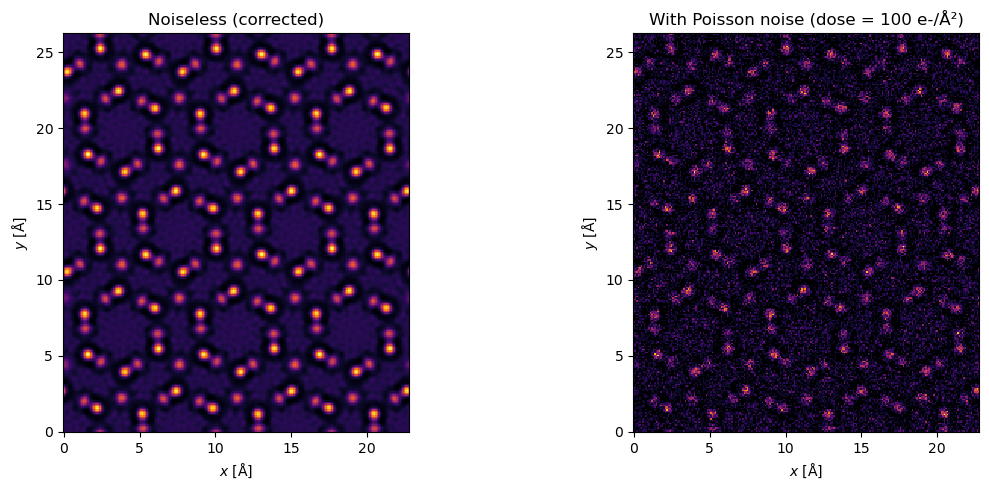

In [15]:
# TASK 4: Apply Poisson noise to the aberration-corrected image
# dose is in electrons per Å²; lower dose -> more noise
dose = 100  # e-/Å²

# First get the noiseless mean intensity image, then add noise
noiseless_image = image_corrected.intensity().mean(0)
noisy_image = noiseless_image.poisson_noise(dose_per_area=dose)

# Plot the noiseless vs noisy images side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

noiseless_image.show(cmap='inferno', ax=axes[0])
axes[0].set_title('Noiseless (corrected)')

noisy_image.show(cmap='inferno', ax=axes[1])
axes[1].set_title(f'With Poisson noise (dose = {dose} e-/Å²)')

plt.tight_layout()
plt.show()


---

# Task 6: Self-Reflection

Based on your simulations above, answer the following questions:

**1. Contrast Transfer Function (CTF):**
- How does the uncorrected CTF differ from the aberration-corrected CTF in terms of spatial frequency transfer?
- Why do we see sharper atomic columns in the aberration-corrected image?

**2. Defocus and Contrast:**
- Why don't we typically image at exactly zero defocus ($\Delta f = 0$) in a conventional (uncorrected) TEM?
- What is the significance of the Scherzer defocus?

**3. Simulation vs. Reality:**
- How does adding Poisson noise change the interpretability of the image?
- What other experimental factors (not simulated here) might degrade the quality of a real HRTEM image?

**4. Multislice Algorithm:**
- Why is the multislice method necessary for a 5 nm thick sample, rather than just using a single projected potential (kinematic approximation)?

### Your Answers:

**1. Contrast Transfer Function (CTF):**

The uncorrected CTF changes sign and oscillates strongly as spatial frequency increases, so some frequency components are transferred well, some are inverted, and others are suppressed entirely. In contrast, the aberration-corrected CTF preserves useful transfer over a wider spatial-frequency range before strong oscillations appear. As a result, more high-frequency information is retained in the corrected case.

The aberration-corrected image shows sharper atomic columns because fine spatial details are transmitted more effectively and with a more favorable phase relationship. This allows the scattered wave components from each atomic column to combine into narrower, more localized intensity peaks, instead of being blurred out by aberration-induced phase distortions.

**2. Defocus and Contrast:**

In a conventional TEM, imaging at exactly zero defocus is usually not useful because a weak-phase object produces very little directly visible contrast there. The sample mainly changes the phase of the electron wave, and some defocus is needed to convert that phase information into measurable image intensity contrast.

The Scherzer defocus is the defocus value chosen to give the best overall contrast transfer at high spatial frequencies in an uncorrected microscope. It provides a practical compromise between defocus and spherical aberration, giving the broadest interpretable transfer range and therefore the clearest lattice or atomic-column contrast.

**3. Simulation vs. Reality:**

Adding Poisson noise makes the image harder to interpret because the intensity now contains shot-noise fluctuations from the finite electron dose. This reduces the visibility of weak features, lowers contrast-to-noise ratio, and makes it more difficult to distinguish true atomic columns from random intensity variations.

In a real HRTEM experiment, image quality can also be degraded by sample drift, specimen tilt, vibrations, limited spatial coherence, chromatic aberration, scan or stage instability, detector imperfections, contamination, thickness variations, and surface amorphous layers. These effects can blur features or introduce contrast variations that are not included in the idealized simulation.

**4. Multislice Algorithm:**

For a 5 nm thick crystalline sample, the electron wave does not simply scatter once from a projected potential. Instead, it propagates through the specimen and is repeatedly modified by successive atomic layers. The multislice method is needed because it accounts for this coupled process of scattering and propagation throughout the thickness of the sample.

A single projected-potential or kinematic approximation is only reasonable for very thin or very weakly scattering samples. At 5 nm, multiple scattering and dynamical diffraction already influence the exit wave, so multislice is necessary to obtain a realistic image simulation.